In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/biohub-cell-tracking-during-development/sample_submission.csv
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/zarr.json
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/zarr.json
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/7/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/47/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/17/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/81/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/19/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/22/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845

# Biohub – Cell Tracking During Development

## Chapter 4: Building Visualization Tools for Nodes, Edges, and Lineages

**Objective:** Build reusable plotting tools to visualize labeled cells, division events, and lineage trajectories directly on the microscopy images.

# 🧠 Background Theory

The previous notebooks taught me how to:

- load `.zarr` image volumes
- load `.geff` tracking graphs
- interpret nodes and edges
- identify a real division event

Now I want to turn that knowledge into reusable tools.

These tools will make later notebooks easier because I’ll be able to quickly answer questions like:

- “Do the labels line up with the image?”
- “What does this lineage do over time?”
- “Does this candidate division actually look like a division?”

# 🗺️ Chapter Roadmap

This notebook will proceed in five stages:

1. **Load one sample and rebuild the node/edge tables**
2. **Create a function to overlay nodes on a slice**
3. **Create a function to visualize a known division event**
4. **Create a function to follow one lineage across time**
5. **Test the tools on the sample `44b6_12dfb391`**

# 📚 New Vocabulary

## Helper Function
A reusable block of code that performs one specific task, such as plotting labels on an image slice.

## Lineage Trajectory
The path a cell follows across time as it moves through the embryo.

## Visualization Utility
A plotting tool built to inspect data repeatedly during later analysis and modeling.

In [2]:
!pip install zarr -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 39.0 MB/s eta 0:00:00


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr

print("zarr version:", zarr.__version__)

zarr version: 3.3.0


In [4]:
competition_path = Path("/kaggle/input/competitions/biohub-cell-tracking-during-development")
train_path = competition_path / "train"

sample_id = "44b6_12dfb391"

zarr_path = train_path / f"{sample_id}.zarr"
geff_path = train_path / f"{sample_id}.geff"

print("Using sample:", sample_id)
print("Zarr exists:", zarr_path.exists())
print("GEFF exists:", geff_path.exists())

Using sample: 44b6_12dfb391
Zarr exists: True
GEFF exists: True


In [5]:
# Load image volume
volume = zarr.open(zarr_path, mode="r")
image = volume["0"]

# Load graph
geff = zarr.open(geff_path, mode="r")

node_ids = geff["nodes/ids"][:]
t_vals = geff["nodes/props/t/values"][:]
z_vals = geff["nodes/props/z/values"][:]
y_vals = geff["nodes/props/y/values"][:]
x_vals = geff["nodes/props/x/values"][:]

nodes_df = pd.DataFrame({
    "node_id": node_ids,
    "t": t_vals,
    "z": z_vals,
    "y": y_vals,
    "x": x_vals
})

edges = geff["edges/ids"][:]
edges_df = pd.DataFrame(edges, columns=["source_id", "target_id"])

print("Image shape:", image.shape)
print("Nodes:", len(nodes_df))
print("Edges:", len(edges_df))

nodes_df.head()

Image shape: (100, 64, 256, 256)
Nodes: 788
Edges: 773


,node_id,t,z,y,x
0,106000000037,0,35,61,189
1,106000000040,0,15,194,55
2,106000000041,0,7,239,56
3,106000000043,0,27,211,109
4,106000000056,0,40,127,130


# Step 3 — Build a Function to Overlay Nodes on an Image Slice

This function will let me choose:

- a timepoint `t`
- a z-slice `z`
- a z-window size

and then plot the image slice with all nearby labeled nodes overlaid.

In [6]:
def plot_nodes_on_slice(image, nodes_df, t, z, z_window=0, figsize=(8, 8)):
    """
    Plot one image slice and overlay labeled nodes from the same timepoint.
    
    Parameters
    ----------
    image : zarr array or numpy-like array
        4D microscopy volume with shape (T, Z, Y, X)
    nodes_df : pandas DataFrame
        Must contain columns: node_id, t, z, y, x
    t : int
        Timepoint to display
    z : int
        Center z-slice to display
    z_window : int, default=0
        Include nodes with z in [z-z_window, z+z_window]
    figsize : tuple
        Matplotlib figure size
    """
    slice_2d = image[t, z]

    nearby_nodes = nodes_df[
        (nodes_df["t"] == t) &
        (nodes_df["z"].between(z - z_window, z + z_window))
    ]

    plt.figure(figsize=figsize)
    plt.imshow(slice_2d, cmap="gray")
    plt.scatter(
        nearby_nodes["x"],
        nearby_nodes["y"],
        s=120,
        facecolors="none",
        edgecolors="red",
        linewidths=2
    )

    for _, row in nearby_nodes.iterrows():
        plt.text(
            row["x"] + 3,
            row["y"] - 3,
            f"z={row['z']}",
            color="yellow",
            fontsize=9
        )

    plt.title(f"Nodes near z={z} ± {z_window} | t={t}")
    plt.axis("off")
    plt.show()

    return nearby_nodes

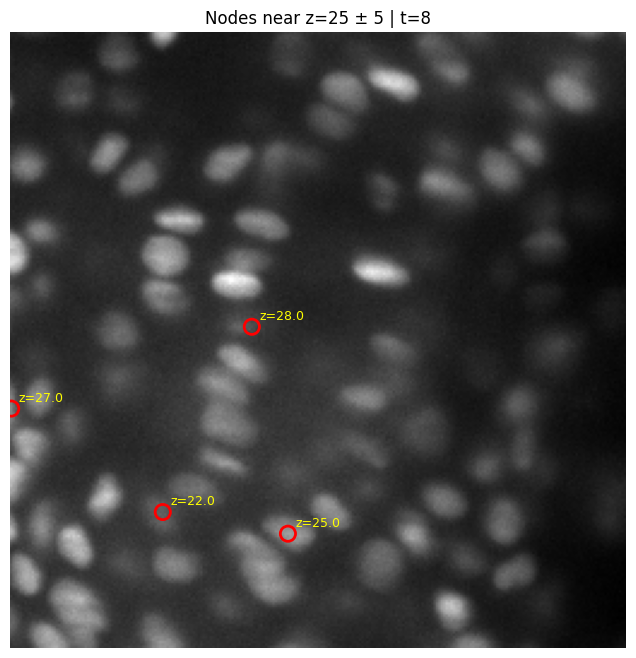

,node_id,t,z,y,x
83,114000000042,8,27,156,0
84,114000000043,8,25,208,115
88,114000000081,8,28,122,100
89,114000000082,8,22,199,63


In [7]:
nearby_nodes = plot_nodes_on_slice(
    image=image,
    nodes_df=nodes_df,
    t=8,
    z=25,
    z_window=5
)

nearby_nodes

# Step 5 — Build a Function to Visualize a Division Event

This function will take:

- a parent node ID
- the node table
- the edge table
- the image volume

and automatically plot:

- the parent cell at its timepoint
- the daughter cells at the next timepoint

This will let me quickly inspect any candidate division event in later notebooks.

In [8]:
def plot_division_event(image, nodes_df, edges_df, parent_id, figsize=(14, 7)):
    """
    Plot a parent cell and its daughter cells across two timepoints.

    Parameters
    ----------
    image : zarr array or numpy-like array
        4D microscopy volume with shape (T, Z, Y, X)
    nodes_df : pandas DataFrame
        Must contain columns: node_id, t, z, y, x
    edges_df : pandas DataFrame
        Must contain columns: source_id, target_id
    parent_id : int
        Node ID of the candidate parent cell
    figsize : tuple
        Matplotlib figure size
    """

    # Find the daughter edges
    daughter_edges = edges_df[edges_df["source_id"] == parent_id]
    daughter_ids = daughter_edges["target_id"].tolist()

    # Build a tiny family table
    family_df = nodes_df[nodes_df["node_id"].isin([parent_id] + daughter_ids)].sort_values("t")

    # Separate parent and daughters
    parent = family_df[family_df["node_id"] == parent_id]
    daughters = family_df[family_df["node_id"].isin(daughter_ids)]

    # Basic safety checks
    if len(parent) != 1:
        raise ValueError(f"Expected exactly 1 parent row for node {parent_id}, found {len(parent)}")
    if len(daughters) == 0:
        raise ValueError(f"No daughter nodes found for parent node {parent_id}")

    parent_t = int(parent["t"].iloc[0])
    z = int(parent["z"].iloc[0])

    # Plot parent and daughters
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Parent frame
    axes[0].imshow(image[parent_t, z], cmap="gray")
    axes[0].scatter(
        parent["x"], parent["y"],
        s=160, facecolors="none", edgecolors="red", linewidths=2
    )
    axes[0].set_title(f"Parent cell | t={parent_t}")
    axes[0].axis("off")

    # Daughter frame
    daughter_t = int(daughters["t"].iloc[0])
    axes[1].imshow(image[daughter_t, z], cmap="gray")
    axes[1].scatter(
        daughters["x"], daughters["y"],
        s=160, facecolors="none", edgecolors="yellow", linewidths=2
    )
    axes[1].set_title(f"Daughter cells | t={daughter_t}")
    axes[1].axis("off")

    plt.show()

    return family_df

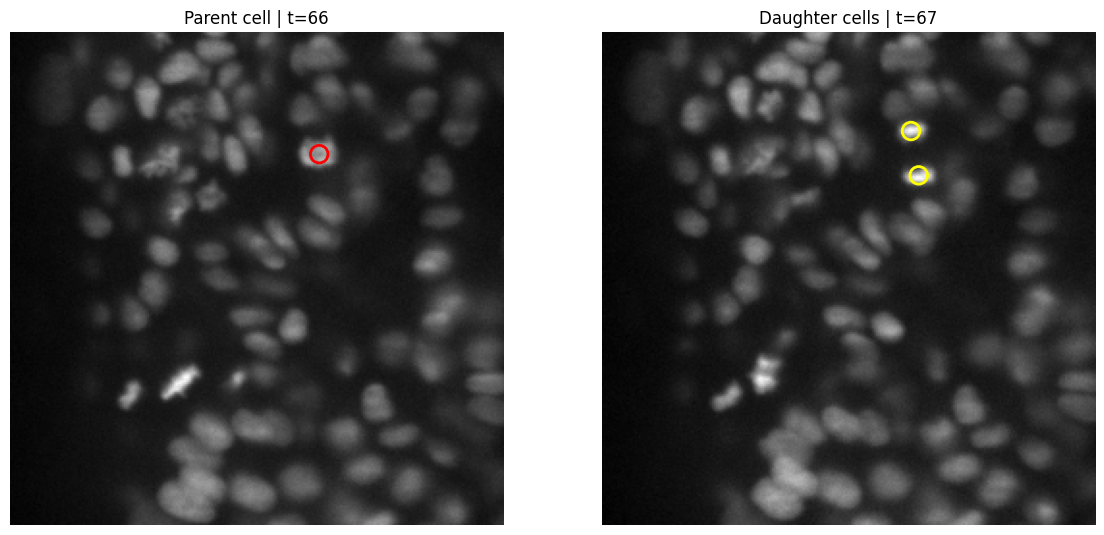

,node_id,t,z,y,x
608,172000000050,66,46,63,160
616,173000000050,67,46,51,160
617,173000000051,67,46,74,164


In [9]:
family_df = plot_division_event(
    image=image,
    nodes_df=nodes_df,
    edges_df=edges_df,
    parent_id=172000000050
)

family_df

# Step 6 — Build a Function to Trace One Lineage Through the Graph

A lineage is a path through the graph.

For this first version, I want a simple tracing rule:

- start from one node ID
- look for its outgoing edge
- if it has exactly one child, follow it
- stop if it has zero children or more than one child

This gives me a clean, non-branching lineage segment that I can visualize across time.

In [10]:
def trace_lineage(nodes_df, edges_df, start_node_id, max_steps=20):
    """
    Follow a lineage forward through the graph as long as each node has exactly one child.

    Parameters
    ----------
    nodes_df : pandas DataFrame
        Must contain columns: node_id, t, z, y, x
    edges_df : pandas DataFrame
        Must contain columns: source_id, target_id
    start_node_id : int
        Node ID where the lineage tracing should begin
    max_steps : int
        Safety limit to avoid infinite loops

    Returns
    -------
    lineage_df : pandas DataFrame
        Rows for the traced lineage nodes, ordered by time
    """
    lineage_ids = [start_node_id]
    current_id = start_node_id

    for _ in range(max_steps):
        children = edges_df.loc[edges_df["source_id"] == current_id, "target_id"].tolist()

        # Stop if no children or if the lineage branches
        if len(children) != 1:
            break

        next_id = children[0]
        lineage_ids.append(next_id)
        current_id = next_id

    lineage_df = nodes_df[nodes_df["node_id"].isin(lineage_ids)].sort_values("t").copy()
    return lineage_df

In [11]:
lineage_df = trace_lineage(
    nodes_df=nodes_df,
    edges_df=edges_df,
    start_node_id=106000000037,
    max_steps=15
)

lineage_df

,node_id,t,z,y,x
0,106000000037,0,35,61,189
10,107000000037,1,35,60,188
20,108000000037,2,36,59,185
30,109000000037,3,36,57,185
40,110000000037,4,36,56,184
50,111000000037,5,36,56,185
60,112000000037,6,36,53,187
70,113000000037,7,37,51,189
80,114000000037,8,37,50,192
91,115000000037,9,38,48,192


# Step 7 — Plot a Lineage Across Time

Now that I can trace a lineage as a table, I want to visualize it.

This function will display several timepoints from the lineage and overlay the tracked cell position on each image slice.

In [12]:
def plot_lineage_over_time(image, lineage_df, max_frames=8, figsize=(16, 8)):
    """
    Plot a tracked lineage across several timepoints.

    Parameters
    ----------
    image : zarr array or numpy-like array
        4D microscopy volume with shape (T, Z, Y, X)
    lineage_df : pandas DataFrame
        Traced lineage table with columns: node_id, t, z, y, x
    max_frames : int
        Maximum number of lineage frames to display
    figsize : tuple
        Matplotlib figure size
    """
    plot_df = lineage_df.head(max_frames).copy()

    n = len(plot_df)
    cols = min(4, n)
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, plot_df.iterrows()):
        t = int(row["t"])
        z = int(row["z"])
        y = int(row["y"])
        x = int(row["x"])

        ax.imshow(image[t, z], cmap="gray")
        ax.scatter([x], [y], s=160, facecolors="none", edgecolors="red", linewidths=2)
        ax.set_title(f"t={t}, z={z}")
        ax.axis("off")

    for ax in axes[len(plot_df):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return plot_df

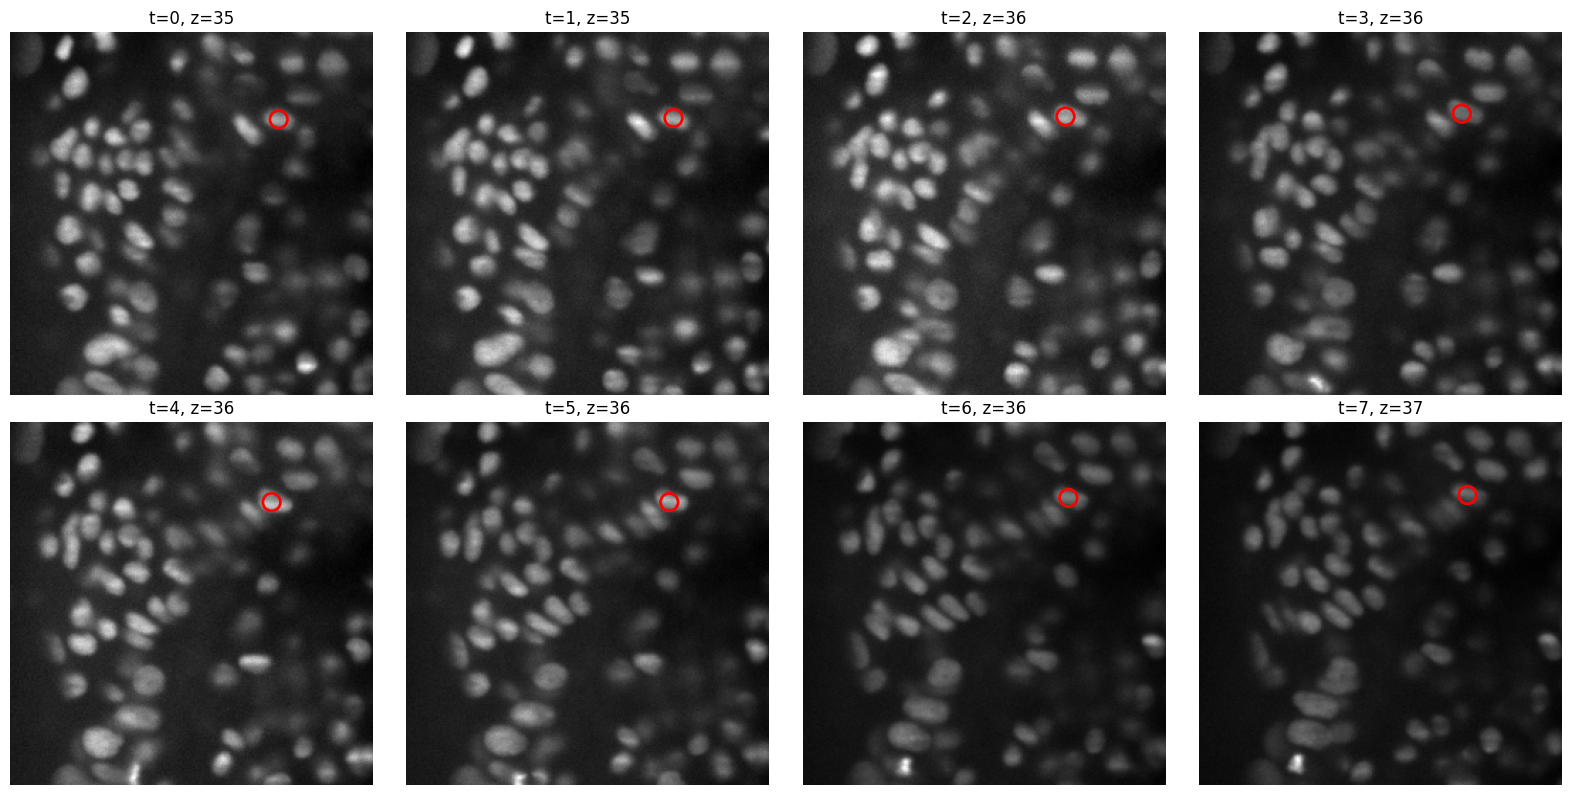

,node_id,t,z,y,x
0,106000000037,0,35,61,189
10,107000000037,1,35,60,188
20,108000000037,2,36,59,185
30,109000000037,3,36,57,185
40,110000000037,4,36,56,184
50,111000000037,5,36,56,185
60,112000000037,6,36,53,187
70,113000000037,7,37,51,189


In [13]:
plot_lineage_df = plot_lineage_over_time(
    image=image,
    lineage_df=lineage_df,
    max_frames=8
)

plot_lineage_df

# Step 8 — Build a Quick Sample Summary Function

Before moving on to modeling, it is helpful to have one small utility that summarizes a sample at a glance.

This function will report:

- number of labeled nodes
- number of edges
- number of labeled timepoints
- maximum number of labels in a single timepoint
- number of candidate division nodes

In [14]:
def summarize_sample(nodes_df, edges_df):
    """
    Return a quick summary of one labeled sample.
    """
    out_degree = edges_df["source_id"].value_counts()
    
    summary = {
        "num_nodes": len(nodes_df),
        "num_edges": len(edges_df),
        "num_labeled_timepoints": nodes_df["t"].nunique(),
        "max_nodes_in_one_timepoint": nodes_df["t"].value_counts().max(),
        "num_division_candidates": int((out_degree >= 2).sum())
    }
    
    return pd.Series(summary)

In [15]:
sample_summary = summarize_sample(nodes_df, edges_df)
sample_summary

num_nodes                     788
num_edges                     773
num_labeled_timepoints        100
max_nodes_in_one_timepoint     11
num_division_candidates         1
dtype: int64

# 📊 Results

In this chapter, I built a reusable visualization toolkit for the Biohub cell-tracking dataset.

## Tools created

### 1. `plot_nodes_on_slice(...)`
This function overlays labeled cell centroids on a chosen microscopy slice, with an optional z-window.

### 2. `plot_division_event(...)`
This function visualizes a parent cell and its daughter cells across two timepoints.

### 3. `trace_lineage(...)`
This function follows a lineage forward through the graph as long as each node has exactly one child.

### 4. `plot_lineage_over_time(...)`
This function visualizes a lineage across multiple timepoints by plotting the tracked cell on the appropriate image slice.

### 5. `summarize_sample(...)`
This function reports basic statistics for a sample, including the number of nodes, edges, labeled timepoints, and candidate division events.

## Sample summary for `44b6_12dfb391`

- **Nodes:** 788
- **Edges:** 773
- **Labeled timepoints:** 100
- **Maximum labeled nodes in one timepoint:** 11
- **Candidate division nodes:** 1

# 🔍 Analysis

## Why this chapter matters

Before training a model, it is important to build intuition about the structure of the data and the behavior of the labels.

This chapter converted one-off exploratory code into reusable tools that can be used throughout the project.

## What these tools make possible

### Fast visual inspection
I can now quickly overlay labeled cells on image slices and verify that the ground-truth coordinates align with visible cells.

### Division inspection
I can inspect candidate division nodes and confirm whether a branching event in the graph looks biologically plausible in the image.

### Lineage tracing
I can follow a cell through time and visualize its trajectory across multiple frames.

### Sample-level understanding
I can summarize a sample in one line and compare different samples before choosing which ones to inspect or use for prototyping.

## Why this matters for the competition

This competition is not only about detecting cell centroids. It is about reconstructing a graph:

- nodes = cells
- edges = temporal links
- branching = divisions

The visualization tools built in this chapter make it easier to debug each of those pieces separately.

# 📝 What I Learned

Today I learned that:

- reusable helper functions make exploratory work much more efficient
- plotting labels directly on microscopy slices is essential for debugging
- division events can be inspected visually once a branching node is identified
- lineage tracing helps turn a graph into a biological story
- a small set of good visualization tools can support every later phase of the competition, including detection, tracking, and error analysis

# 🚀 Next Steps

## Chapter 5 — Baseline Cell Detection on a Single Timepoint

The next step is to move from visualization to the first piece of modeling: **cell detection**.

In Chapter 5, I want to build a simple baseline that predicts cell locations for a single 3D frame.

Possible goals:

- choose one labeled timepoint from one training sample
- use the node coordinates as target points
- create a simple method to detect bright cell-like blobs
- compare detected points to ground-truth centroids visually
- begin thinking about how a full node-detection model might work